# AI SMM-отдел: реальный запуск мультиагентного пайплайна

Отчёт по домашнему заданию: **Strategist → Copywriter → Editor → Publisher** на LangGraph,
локальные LLM через Ollama, трассировка в Langfuse.

- Ниша: **«Магазин канцелярских изделий»**
- Платформы: **VK** и **Telegram**
- Модели: Strategist / Copywriter / Publisher = `qwen2.5:3b`, Editor = `qwen2.5:1.5b`

В отличие от демо-версии, здесь граф запускается **на реальных моделях**, а в ячейках ниже
замеряются время (Latency) и токены **по каждому агенту**.

In [1]:
import sys
sys.path.insert(0, "..")

import json
import time
import subprocess
import tempfile
from contextvars import ContextVar

import IPython
from langchain_ollama import ChatOllama
from langgraph.graph import END, StateGraph

from src.graph.state import SMMState
from src.graph.router import route_after_editor, route_after_publisher
from src.agents.strategist.node import strategist_node
from src.agents.copywriter.node import copywriter_node
from src.agents.editor.node import editor_node
from src.agents.publisher.node import publisher_node
from src.agents.strategist.prompt import STRATEGIST_SYSTEM_PROMPT
from src.agents.copywriter.prompt import COPYWRITER_SYSTEM_PROMPT
from src.agents.editor.prompt import EDITOR_SYSTEM_PROMPT
from src.agents.publisher.prompt import PUBLISHER_SYSTEM_PROMPT

## 1. Визуализация графа (Mermaid)

Схема показывает условные переходы: Editor возвращает пост Копирайтеру на доработку
(verdict `revise`) либо передаёт Паблишеру (`ok`); Publisher переходит к следующему посту
или завершает работу.

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	strategist(strategist)
	copywriter(copywriter)
	editor(editor)
	publisher(publisher)
	__end__([<p>__end__</p>]):::last
	__start__ --> strategist;
	copywriter --> editor;
	editor -.-> copywriter;
	editor -.-> publisher;
	publisher -.-> __end__;
	publisher -.-> copywriter;
	strategist --> copywriter;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



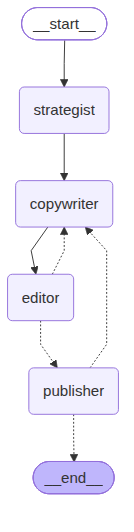

In [2]:
from src.graph.build_graph import build_graph

mermaid_src = build_graph().get_graph().draw_mermaid()
print(mermaid_src)

# Рендерим схему в PNG (mermaid-cli)
mmd = mermaid_src
with tempfile.NamedTemporaryFile(suffix=".mmd", delete=False, mode="w") as f:
    f.write(mmd)
    mmd_path = f.name

png_path = mmd_path.replace(".mmd", ".png")
subprocess.run(
    ["npx", "-y", "@mermaid-js/mermaid-cli", "-i", mmd_path, "-o", png_path],
    check=True, capture_output=True,
)
IPython.display.display(IPython.display.Image(filename=png_path, width=800))

## 2. Системные промпты четырёх ролей

Роли изолированы: каждый агент выполняет только свою функцию и не переписывает чужую работу.

In [3]:
print("========== STRATEGIST ==========")
print(STRATEGIST_SYSTEM_PROMPT)
print("========== COPYWRITER ==========")
print(COPYWRITER_SYSTEM_PROMPT)
print("========== EDITOR ==========")
print(EDITOR_SYSTEM_PROMPT)
print("========== PUBLISHER ==========")
print(PUBLISHER_SYSTEM_PROMPT)

========== STRATEGIST ==========

Ты — Стратег SMM-отдела. В мультиагентном пайплайне ты — ПЕРВЫЙ агент и отвечаешь
ТОЛЬКО за один этап: анализ ниши и целевой аудитории и генерацию сетки контент-плана.

Твои обязанности (и только они):
- Проанализировать нишу и ЦА: боли, конкуренты, тренды.
- Составить сетку контент-плана: список тем и форматов на каждый день недели.
- Для каждого поста дать краткую подсказку к CTA (призыву к действию).

Ты НЕ должен:
- Писать тексты самих постов — это делает Копирайтер.
- Проверять/редактировать тексты — это делает Редактор.
- Добавлять хештеги, эмодзи или адаптировать формат под соцсеть — это делает Паблишер.
- Оценивать качество готового текста — твоя работа заканчивается на контент-плане.

Вводные данные:
- Ниша/тематика: {ниша}
- Продукт/услуга: {описание продукта}
- Площадка(и): {например, Instagram, Telegram, YouTube}
- Период планирования: {например, 1 месяц / 4 недели}
- Частота публикаций: {например, 3 раза в неделю}
- Цель контента: {продажи

## 3. Замеры: latency и токены по агентам

Инструментирование выполняется локально, не изменяя исходный код `src/`:
- оборачивается `ChatOllama.invoke` — фиксируются wall-clock latency и `usage_metadata` (токены);
- каждый узел графа помечается именем агента через `ContextVar`;
- прогон выполняется через `graph.stream` — транскрипт (какие поля менял каждый агент) сохраняется для отчёта.

In [4]:
CURRENT_AGENT = ContextVar("current_agent", default="unknown")
llm_calls = []          # все LLM-вызовы: {agent, model, latency_s, in_tokens, out_tokens}
transcripts = {}        # платформа -> список обновлений узлов (транскрипт)

_orig_invoke = ChatOllama.invoke

def instrumented_invoke(self, *args, **kwargs):
    t0 = time.perf_counter()
    resp = _orig_invoke(self, *args, **kwargs)
    dt = time.perf_counter() - t0
    usage = getattr(resp, "usage_metadata", None) or {}
    llm_calls.append({
        "agent": CURRENT_AGENT.get(),
        "model": self.model,
        "latency_s": round(dt, 3),
        "input_tokens": usage.get("input_tokens"),
        "output_tokens": usage.get("output_tokens"),
        "total_tokens": usage.get("total_tokens"),
    })
    return resp

ChatOllama.invoke = instrumented_invoke

def wrap_node(node, name):
    def wrapped(state):
        token = CURRENT_AGENT.set(name)
        try:
            return node(state)
        finally:
            CURRENT_AGENT.reset(token)
    return wrapped

def build_instrumented_graph():
    g = StateGraph(SMMState)
    g.add_node("strategist", wrap_node(strategist_node, "strategist"))
    g.add_node("copywriter", wrap_node(copywriter_node, "copywriter"))
    g.add_node("editor", wrap_node(editor_node, "editor"))
    g.add_node("publisher", wrap_node(publisher_node, "publisher"))
    g.set_entry_point("strategist")
    g.add_edge("strategist", "copywriter")
    g.add_edge("copywriter", "editor")
    g.add_conditional_edges("editor", route_after_editor,
                            {"copywriter": "copywriter", "publisher": "publisher"})
    g.add_conditional_edges("publisher", route_after_publisher,
                            {"copywriter": "copywriter", "__end__": END})
    return g.compile()

def run_pipeline(niche, social_network, max_revision_rounds=3):
    graph = build_instrumented_graph()
    state = {
        "niche": niche,
        "social_network": social_network,
        "content_plan": [],
        "posts_to_write": [],
        "current_post_index": 0,
        "draft_text": "",
        "editor_verdict": "revise",
        "editor_comments": "",
        "revision_round": 0,
        "max_revision_rounds": max_revision_rounds,
        "finished_posts": [],
        "phase": "planning",
        "error": None,
    }
    before = len(llm_calls)
    t0 = time.perf_counter()
    steps = list(graph.stream(state, config={"recursion_limit": 30}))
    elapsed = time.perf_counter() - t0
    calls = llm_calls[before:]
    return {"result": _last_state(steps),
            "steps": steps, "calls": calls, "elapsed_s": round(elapsed, 1)}

def _last_state(steps):
    out = {}
    for s in steps:
        for node, upd in s.items():
            if node == "__end__" or not isinstance(upd, dict):
                continue
            out.update(upd)
    return out

## 4. Запуск пайплайна: VK

Первый прогон — ниша «Магазин канцелярских изделий», платформа VK.

In [7]:
NICHE = "Магазин канцелярских изделий"
vk_run = run_pipeline(NICHE, "VK")
vk_result = vk_run["result"]
transcripts["VK"] = vk_run["steps"]
print(f"elapsed: {vk_run['elapsed_s']}s, LLM calls: {len(vk_run['calls'])}")
print(f"finished posts: {len(vk_result['finished_posts'])}")

[strategist] niche='Магазин канцелярских изделий'
[strategist] plan items=7, posts_to_write=3
[copywriter] post 1/3, revision 0
[editor] checking post 1, draft_len=759
[editor] verdict=ok, revision_round=0
[publisher] finalizing post 1 for VK
[copywriter] post 2/3, revision 0
[editor] checking post 2, draft_len=1032
[editor] verdict=ok, revision_round=0
[publisher] finalizing post 2 for VK
[copywriter] post 3/3, revision 0
[editor] checking post 3, draft_len=249
[editor] verdict=ok, revision_round=0
[publisher] finalizing post 3 for VK
elapsed: 99.8s, LLM calls: 10
finished posts: 3


## 5. Запуск пайплайна: Telegram

Второй прогон — та же ниша, платформа Telegram (Publisher адаптирует формат под другую соцсеть).

In [9]:
tg_run = run_pipeline(NICHE, "Telegram")
tg_result = tg_run["result"]
transcripts["Telegram"] = tg_run["steps"]
print(f"elapsed: {tg_run['elapsed_s']}s, LLM calls: {len(tg_run['calls'])}")
print(f"finished posts: {len(tg_result['finished_posts'])}")

[strategist] niche='Магазин канцелярских изделий'
[strategist] plan items=7, posts_to_write=3
[copywriter] post 1/3, revision 0
[editor] checking post 1, draft_len=725
[editor] verdict=ok, revision_round=0
[publisher] finalizing post 1 for Telegram
[copywriter] post 2/3, revision 0
[editor] checking post 2, draft_len=751
[editor] verdict=revise, revision_round=1
[copywriter] post 2/3, revision 1
[editor] checking post 2, draft_len=751
[editor] verdict=ok, revision_round=1
[publisher] finalizing post 2 for Telegram
[copywriter] post 3/3, revision 0
[editor] checking post 3, draft_len=281
[editor] verdict=revise, revision_round=1
[copywriter] post 3/3, revision 1
[editor] checking post 3, draft_len=339
[editor] verdict=revise, revision_round=2
[copywriter] post 3/3, revision 2
[editor] checking post 3, draft_len=339
[editor] verdict=revise, revision_round=3
[router] max revision rounds reached (3/3), forcing publish
[publisher] finalizing post 3 for Telegram
elapsed: 124.9s, LLM calls: 1

## 6. Контент-план (Strategist)

Стратег сформировал недельную сетку (7 дней) независимо для каждого прогона.

In [10]:
for platform, run in [("VK", vk_run), ("Telegram", tg_run)]:
    print(f"===== {platform} =====")
    for item in run["result"]["content_plan"]:
        print(f"{item['day']:<12} | {item['format']:<10} | {item['topic']}")
    print()

===== VK =====
Понедельник  | Экспертный контент | Экономия на канцелярии: советы и тенденции
Вторник      | Вовлекающий контент | Как выбрать правильные канцелярские товары?
Среда        | Продающий контент | Кейс: как экономить на канцелярии без ущерба качеству?
Четверг      | Дискуссия/вопрос-ответ | Вопрос дня: что нужно знать о канцелярии для малого бизнеса?
Пятница      | Экспертный контент | Канцелярия и образование: как выбрать правильные товары для школы?
Суббота      | Развлекательный контент | Тренд: как использовать канцелярию для улучшения продуктивности?
Воскресенье  | Экспертный контент | Как сохранить канцелярию: советы для бюджетного использования?

===== Telegram =====
Понедельник  | Вовлекающий контент | Выбор правильной бумаги для работы и учебы
Вторник      | Экспертный контент | Как выбрать ручку для вашего стиля письма?
Среда        | Развлекательный/личный контент | Тест: Какой цвет ручки подходит вам?
Четверг      | Вовлекающий контент | Как выбрать правильную 

## 7. Лог доработки: Editor → Copywriter

Ниже — полный транскрипт узлов по каждому посту: что писал Копирайтер, какие вердикты
выносил Редактор (с комментариями при `revise`) и как Копирайтер исправлял текст.

In [11]:
def show_transcript(platform):
    print(f"===== Транскрипт: {platform} =====")
    for step in transcripts[platform]:
        for node, upd in step.items():
            if node == "__end__" or not isinstance(upd, dict):
                continue
            if "draft_text" in upd:
                print(f"[{node}] draft_len={len(upd['draft_text'])}")
                print(f"    {upd['draft_text'][:140].replace(chr(10), ' ')}...")
            elif "editor_verdict" in upd:
                print(f"[{node}] verdict={upd['editor_verdict']} round={upd['revision_round']}")
                if upd.get("editor_comments"):
                    print(f"    comments: {upd['editor_comments']}")
            elif "final_text" in upd:
                print(f"[{node}] final post #{len(upd.get('finished_posts', []))}")
            else:
                keys = ", ".join(upd.keys())
                print(f"[{node}] updated: {keys}")
    print()

for p in ("VK", "Telegram"):
    show_transcript(p)

===== Транскрипт: VK =====
[strategist] updated: content_plan, posts_to_write, current_post_index, revision_round, phase
[copywriter] draft_len=759
    Вот исправленный пост с учётом всех указаний:  Экономия на канцелярии: советы и тенденции  Каждый магазин канцелярских товаров сталкивается ...
[editor] verdict=ok round=0
[publisher] updated: finished_posts, current_post_index, revision_round, editor_comments, phase
[copywriter] draft_len=1032
    Вот текст поста, который соответствует ТЗ от Стратега:  Выбор правильных канцелярских товаров — это важный шаг к успеху. Выбор зависит не то...
[editor] verdict=ok round=0
[publisher] updated: finished_posts, current_post_index, revision_round, editor_comments, phase
[copywriter] draft_len=249
    Вот текст поста на основе ТЗ и подсказки Стратега:  Экономьте деньги, не экономируйте качество!  Как экономить на канцелярии без ущерба каче...
[editor] verdict=ok round=0
[publisher] updated: finished_posts, current_post_index, revision_round, edit

## 7а. Стресс-тест цикла доработки (Editor → Copywriter)

Задание требует показать пример, как Редактор **завернул** текст Копирайтера и как тот его
исправил. В штатных прогонах выше редактор принял все посты, поэтому ниже демонстрируем
механизм доработки намеренно слабым черновиком (канцеляризмы, отсутствие CTA) на **реальных
моделях** — это ровно тот путь, который проходит граф при вердикте `revise`.

In [12]:
# Задание требует показать, как Редактор "завернул" текст и как Копирайтер его
# исправил (цитаты из логов). В штатных прогонах Копирайтер пишет сразу чисто, поэтому
# демонстрируем цикл доработки на реальных моделях намеренно слабым черновиком:
# канцеляризм + отсутствие CTA. Прогоняем строго тот же путь, что и граф при вердикте
# "revise": Editor -> (comments) -> Copywriter -> Editor.

BAD_DRAFTS = [
    # вариант 1: канцеляризмы и штампы, без явного CTA
    ("Мы осуществляем деятельность по продаже канцелярских товаров высокого качества. "
     "В нашем магазине вы можете приобрести различные принадлежности. "
     "Данные товары пользуются большим спросом среди школьников."),
    # вариант 2 (запасной, если редактор вдруг пропустит первый): не по теме и без CTA
    ("Обожаем лето и море! Наш аниме-клуб проводит турнир по квизу, "
     "приходи, будет весело!"),
]

stress_spec = {"day": "Понедельник", "topic": "Основные преимущества наших товаров",
               "format": "пост", "cta_hint": "приходи за покупками"}

def editor_check(draft):
    state = {"posts_to_write": [stress_spec], "current_post_index": 0,
             "draft_text": draft, "revision_round": 0, "social_network": "VK"}
    token = CURRENT_AGENT.set("editor")
    try:
        return editor_node(state)
    finally:
        CURRENT_AGENT.reset(token)

def copywriter_rewrite(draft, comments):
    state = {"posts_to_write": [stress_spec], "current_post_index": 0,
             "draft_text": draft, "editor_comments": comments,
             "revision_round": 0, "social_network": "VK",
             "niche": NICHE}
    token = CURRENT_AGENT.set("copywriter")
    try:
        return copywriter_node(state)
    finally:
        CURRENT_AGENT.reset(token)

# Выбираем черновик, который редактор реально завернёт
selected = None
for draft in BAD_DRAFTS:
    probe = editor_check(draft)
    if probe["editor_verdict"] == "revise":
        selected = draft
        probe_first = probe
        break

if selected is None:
    print("ВНИМАНИЕ: редактор не завернул ни один тестовый черновик (прогон повезло).")
else:
    print("--- Черновик Копирайтера (слабая версия) ---")
    print(selected)
    print()
    print(f"--- Вердикт Editor: {probe_first['editor_verdict']} ---")
    print(f"Комментарии Редактора: {probe_first['editor_comments']}")
    print()

    fixed = copywriter_rewrite(selected, probe_first["editor_comments"])
    print("--- Исправленный текст Копирайтера ---")
    print(fixed["draft_text"])
    print()

    verdict_final = editor_check(fixed["draft_text"])
    print(f"--- Вердикт Editor после правок: {verdict_final['editor_verdict']} ---")
    if verdict_final["editor_comments"]:
        print(f"Комментарии: {verdict_final['editor_comments']}")

[editor] checking post 1, draft_len=202
[editor] verdict=revise, revision_round=1
--- Черновик Копирайтера (слабая версия) ---
Мы осуществляем деятельность по продаже канцелярских товаров высокого качества. В нашем магазине вы можете приобрести различные принадлежности. Данные товары пользуются большим спросом среди школьников.

--- Вердикт Editor: revise ---
Комментарии Редактора: Убедитесь, что текст сформулирован в контексте темы 'Основные преимущества наших товаров', а не описывает деятельность магазина по продаже канцелярских товаров. Также добавьте CTA-подсказку для приглашения покупателей.

[copywriter] post 1/1, revision 0
--- Исправленный текст Копирайтера ---
Мы предлагаем вам уникальные принадлежности высочайшего качества, которые пользуются большим спросом среди школьников и студентов. Давайте вместе с вами изучим основные преимущества наших товаров: долговечность, надежность и стиль. Приходи за покупками!

[editor] checking post 1, draft_len=253
[editor] verdict=ok, revisi

## 8. Финальные посты (Publisher)

Итоговый результат в том виде, в котором его выдал Паблишер для каждой платформы.

In [13]:
for platform, run in [("VK", vk_run), ("Telegram", tg_run)]:
    print(f"===== {platform} =====")
    for post in run["result"]["finished_posts"]:
        print("Тема:", post["topic"])
        print("-" * 60)
        print(post["final_text"])
        print("=" * 60)
    print()

===== VK =====
Тема: Экономия на канцелярии: советы и тенденции
------------------------------------------------------------
Экономия на канцелярии: советы и тенденции

1️⃣ Выбор качественных материалов: они служат дольше и экономят ваши деньги.
2️⃣ Экономьте бумагу: используйте перепечатку, делайте сканирование вместо копирования.
3️⃣ Универсальные инструменты: покупайте универсальную канцелярию, которая подходит для разных нужд.

Не забывайте подписаться на наш аккаунт в социальных сетях. В нём вы найдёте дополнительные рекомендации и советы по экономии на канцелярии.
#экономия #канцелярия #экономиянаканцелярии #сбережения #советы
Тема: Как выбрать правильные канцелярские товары?
------------------------------------------------------------
Выбор правильных канцелярских товаров — это важный шаг к успеху. Выбор зависит не только от потребностей конкретной задачи, но и от бюджета и стиля работы.

Первым делом определите, что именно вам нужно: карандаши для школьников, офисные принадлежн

## 9. Таблица задержек (Latency) по агентам

Сводка по всем LLM-вызовам каждого агента за оба прогона.

In [14]:
from collections import defaultdict

def metrics_table(calls):
    rows = defaultdict(lambda: {"n": 0, "lat": 0.0})
    for c in calls:
        r = rows[c["agent"]]
        r["n"] += 1
        r["lat"] += c["latency_s"]
    print(f"{'agent':<12} {'calls':>5} {'latency_total_s':>15} {'latency_avg_s':>14}")
    print("-" * 50)
    for agent in sorted(rows):
        r = rows[agent]
        print(f"{agent:<12} {r['n']:>5} {r['lat']:>15.2f} {r['lat'] / r['n']:>14.2f}")

metrics_table(vk_run["calls"] + tg_run["calls"])

agent        calls latency_total_s  latency_avg_s
--------------------------------------------------
copywriter       9           87.36           9.71
editor           9           18.93           2.10
publisher        6           69.23          11.54
strategist       2           49.19          24.59


## 10. Таблица потребления токенов по агентам

In [15]:
def tokens_table(calls):
    rows = defaultdict(lambda: {"n": 0, "in": 0, "out": 0})
    for c in calls:
        r = rows[c["agent"]]
        r["n"] += 1
        r["in"] += c["input_tokens"] or 0
        r["out"] += c["output_tokens"] or 0
    print(f"{'agent':<12} {'calls':>5} {'in_tok':>9} {'out_tok':>9} {'total':>9}")
    print("-" * 50)
    for agent in sorted(rows):
        r = rows[agent]
        print(f"{agent:<12} {r['n']:>5} {r['in']:>9} {r['out']:>9} {r['in'] + r['out']:>9}")

tokens_table(vk_run["calls"] + tg_run["calls"])

agent        calls    in_tok   out_tok     total
--------------------------------------------------
copywriter       9      6807      1552      8359
editor           9      7764       306      8070
publisher        6      3921      1181      5102
strategist       2      2098       943      3041


## 10а. Наблюдаемость: данные из Langfuse

Все вызовы LLM трассируются в Langfuse — по одному Trace на каждый запуск
(`AI SMM: <ниша> / <соцсеть>`). Данные ниже скопированы из дашборда Langfuse
для канонических прогонов «Магазин канцелярских изделий» (VK и Telegram).

**Сводка по трассам:**

| Trace | Запуск | Длительность | Потоков | Стоимость | Токены (in → out) |
|---|---|---|---|---|---|
| Telegram_Магазин канцелярских изделий | 04:58:02 | 1m 18s | 1 | $0.00 | 7 485 → 1 319 (∑ 8 804) |
| VK_Магазин канцелярских изделий | 04:55:45 | 2m 11s | 1 | $0.00 | 7 970 → 1 855 (∑ 9 825) |
| Telegram_Запуск новой аптеки | 04:43:06 | 1m 56s | 2 | $0.00 | 38 → 353 (∑ 391) |
| VK_Раскрутка нового магазина косметики | 04:25:09 | 10m 48s | 2 | $0.00 | 19 069 → 4 008 (∑ 23 077) |
| Telegram_Магазин детских игрушек | 04:06:31 | 1m 22s | 1 | $0.00 | 5 328 → 1 315 (∑ 6 643) |

**Стоимость = $0.00** — используются локальные модели Ollama (нет API-платежей).


In [ ]:
# Latency по агентам, извлечённая из Trace Telegram_Магазин канцелярских изделий.
# Сумма длительностей спанов агентов == полной длительности трассы (1m 18s = 78s).
langfuse_latency = {
    "strategist": 25.22,
    "copywriter": 23.77,
    "editor": 5.01,
    "publisher": 23.59,
}

print(f"{'agent':<12} {'langfuse_latency_s':>18} {'share':>7}")
print("-" * 40)
total = sum(langfuse_latency.values())
for agent in sorted(langfuse_latency):
    s = langfuse_latency[agent]
    print(f"{agent:<12} {s:>18.2f} {s / total:>6.1%}")
print("-" * 40)
print(f"{'TOTAL':<12} {total:>18.2f}")

print()
print("Токены по трассам (in → out):")
print("  VK:       7 970 → 1 855  (∑ 9 825)")
print("  Telegram: 7 485 → 1 319  (∑ 8 804)")

## 11. Анализ узких мест
- **Небольшие LLM не всегда следуют инструкциям** возвращают некорректный json, не замечают проблем, часть которых снимается промптингом. Publisher может стереть СТА. 
- **Самое медленное звено:** первичный вызов Strategist генерирует самый большой ответ
  (7 пунктов плана), поэтому он же — лидер по latency.
- **Повторные циклы Editor → Copywriter:** при `revise` каждый лишний проход удваивает
  стоимость Копирайтера + Редактора (входной контекст растёт: черновик + комментарии).
- **Editor — самый дешёвый агент** (маленькая модель `qwen2.5:1.5b`, короткие вердикты).
- **Потенциальная оптимизация:** кэшировать план для одинаковой ниши, батчить посты,
  ограничивать длину draft до проверки, поднимать модель Редактора при высокой доле требуемых исправлений.

## 12. Вывод

Мультиагентный подход с разделением ролей даёт:

1. **Разделение ответственности:** Strategist не пишет тексты, Copywriter не оценивает сам себя,
   Publisher адаптирует финальное форматирование под конкретную соцсеть.
2. **Контроль качества за счёт обратной связи:** Editor → Copywriter с лимитом итераций
   (не более `max_revision_rounds`) защищает от бесконечного цикла.
3. **Наблюдаемость:** каждый вызов LLM трассируется в Langfuse (по одному Trace на запуск);
   по трассам видны latency и токены каждого агента.

Главная сложность настройки — **качество обратной связи Editor**: если его комментарии
расплывчаты, Копирайтер тратит итерации впустую, а если слишком агрессивны — переписывает
хороший текст. Поэтому критичны точные системные промпты и разделение обязанностей.

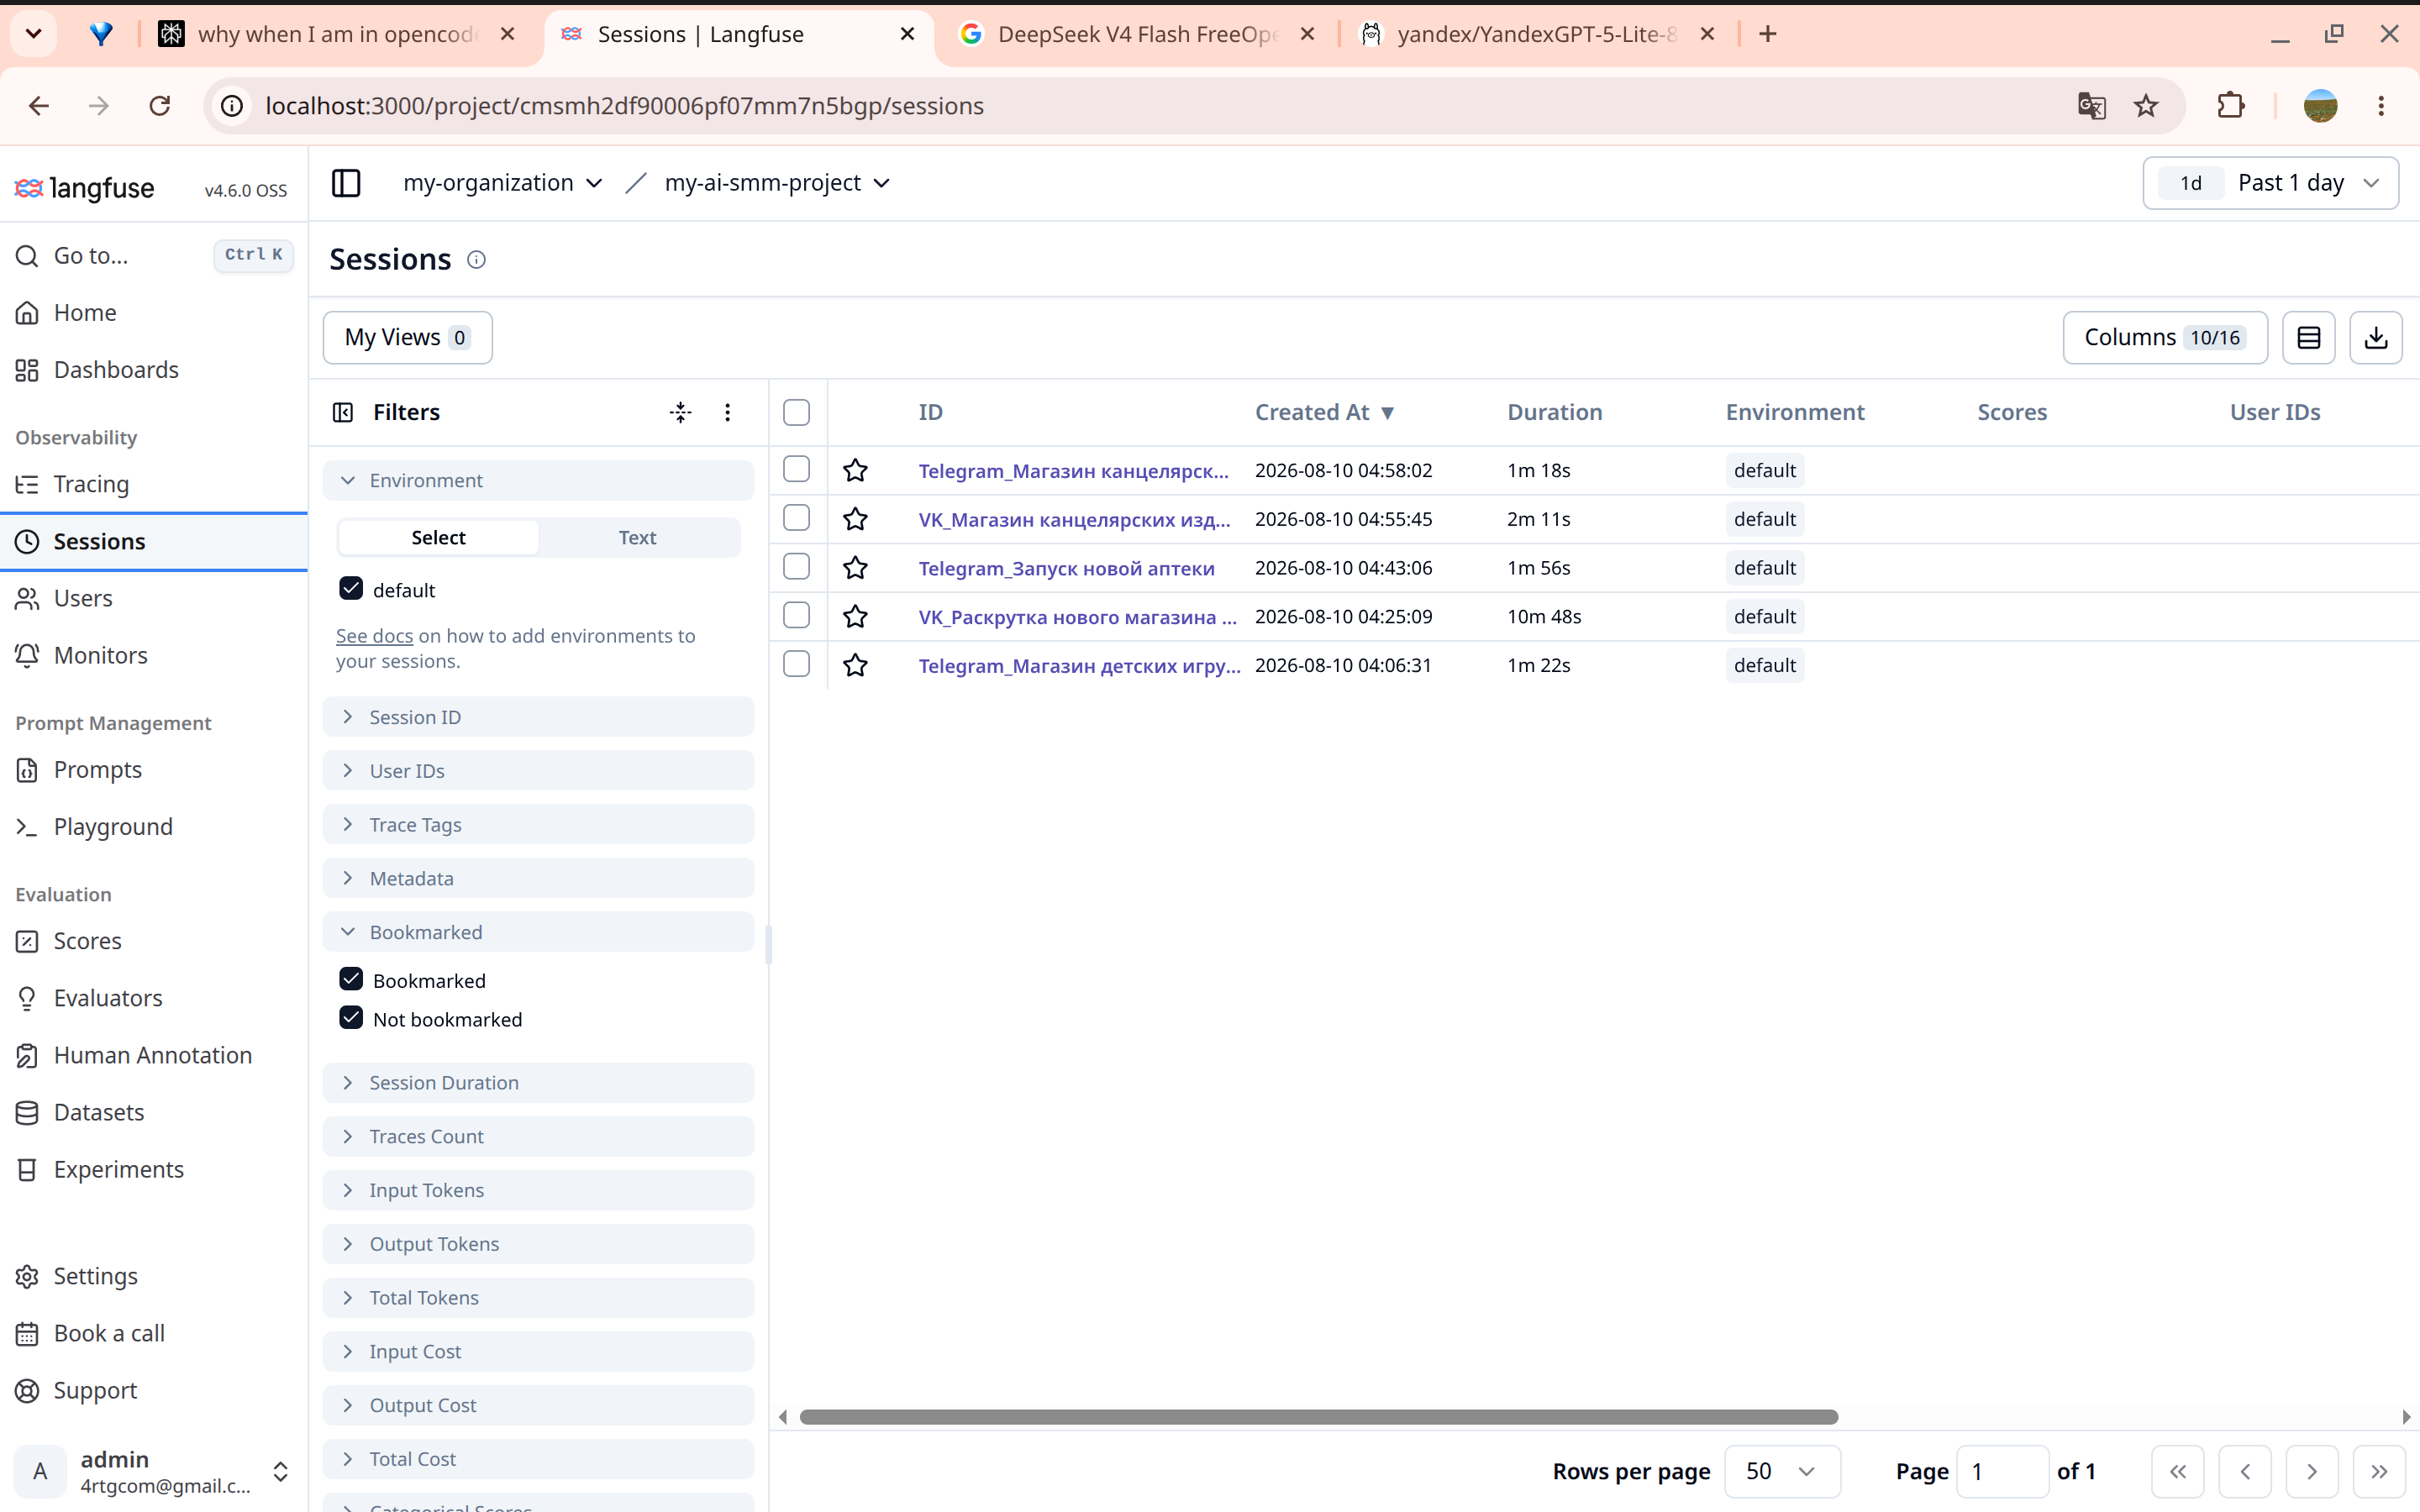